In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit, cross_validate

/Users/nguyentuankhang/Documents/Projects/Datathon.2026/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_daily= pd.read_parquet('../dataset/processed_data_daily.parquet')

In [3]:
final_features=['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
                'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 
                
                'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 'profit_lag_7', 'profit_lag_365', 
                'margin_rate_lag_7', 'margin_rate_lag_365', 
                
                'month', 'is_promoted', 
                'avg_discount_pct', 'max_discount_pct',

                'is_Spring_promotion', 'is_MidYear_promotion', 'is_FallLauch_promotion',
                'is_YearEnd_promotion', 'is_Rural_promotion', 'is_Urban_promotion',
                'category_promotion', 'chanel_promotion']

In [4]:
# 1. Xác định Target và Features
target = 'Revenue'
# 2. Tách dữ liệu theo thời gian (Ví dụ: lấy 2 tháng cuối 2022 để kiểm tra)
train_data = df_daily[df_daily['Date'] < '2022-11-01']
val_data = df_daily[df_daily['Date'] >= '2022-11-01']

# 3. Tạo bộ X (câu hỏi) và y (đáp án)
X_train = train_data[final_features]
y_train = train_data[target]

X_val = val_data[final_features]
y_val = val_data[target]

print(f"Đã sẵn sàng! Train: {X_train.shape}, Val: {X_val.shape}")

Đã sẵn sàng! Train: (3772, 28), Val: (61, 28)


In [5]:
def objective(trial):
    # 1. Khai báo các "nút vặn" cần tìm
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    # 2. Chạy thử mô hình với bộ tham số này
    model = XGBRegressor(**param, tree_method='hist', random_state=42) # Dùng hist để chạy cho nhanh
    model.fit(X_train, y_train)
    
    # 3. Tính sai số trên tập Validation (Nhớ dùng Time Series Split để test cho chuẩn)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    return rmse

# 4. Bắt đầu cuộc đi tìm "kho báu"
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=50) 

print("Bộ tham số xịn nhất đây rồi:", study.best_params)

[I 2026-04-28 16:40:15,099] A new study created in memory with name: no-name-6edbdbfa-29a2-4339-aa90-5cb55c57f398


[I 2026-04-28 16:40:19,443] Trial 0 finished with value: 229503.4598022309 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'learning_rate': 0.05395030966670229, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124}. Best is trial 0 with value: 229503.4598022309.
[I 2026-04-28 16:40:23,529] Trial 1 finished with value: 226740.4650798163 and parameters: {'n_estimators': 1800, 'max_depth': 7, 'learning_rate': 0.051059032093947576, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 2.136832907235876, 'reg_lambda': 0.0070689749506246055}. Best is trial 1 with value: 226740.4650798163.
[I 2026-04-28 16:40:24,354] Trial 2 finished with value: 207930.6698556328 and parameters: {'n_estimators': 772, 'max_depth': 4, 'learning_rate': 0.02014847788415866, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'reg_alpha': 0.014618962793704969, 'reg_

Bộ tham số xịn nhất đây rồi: {'n_estimators': 1953, 'max_depth': 3, 'learning_rate': 0.022210899333379032, 'subsample': 0.5897585582641189, 'colsample_bytree': 0.99483762099123, 'reg_alpha': 0.10802790127558719, 'reg_lambda': 0.0100321642152161}


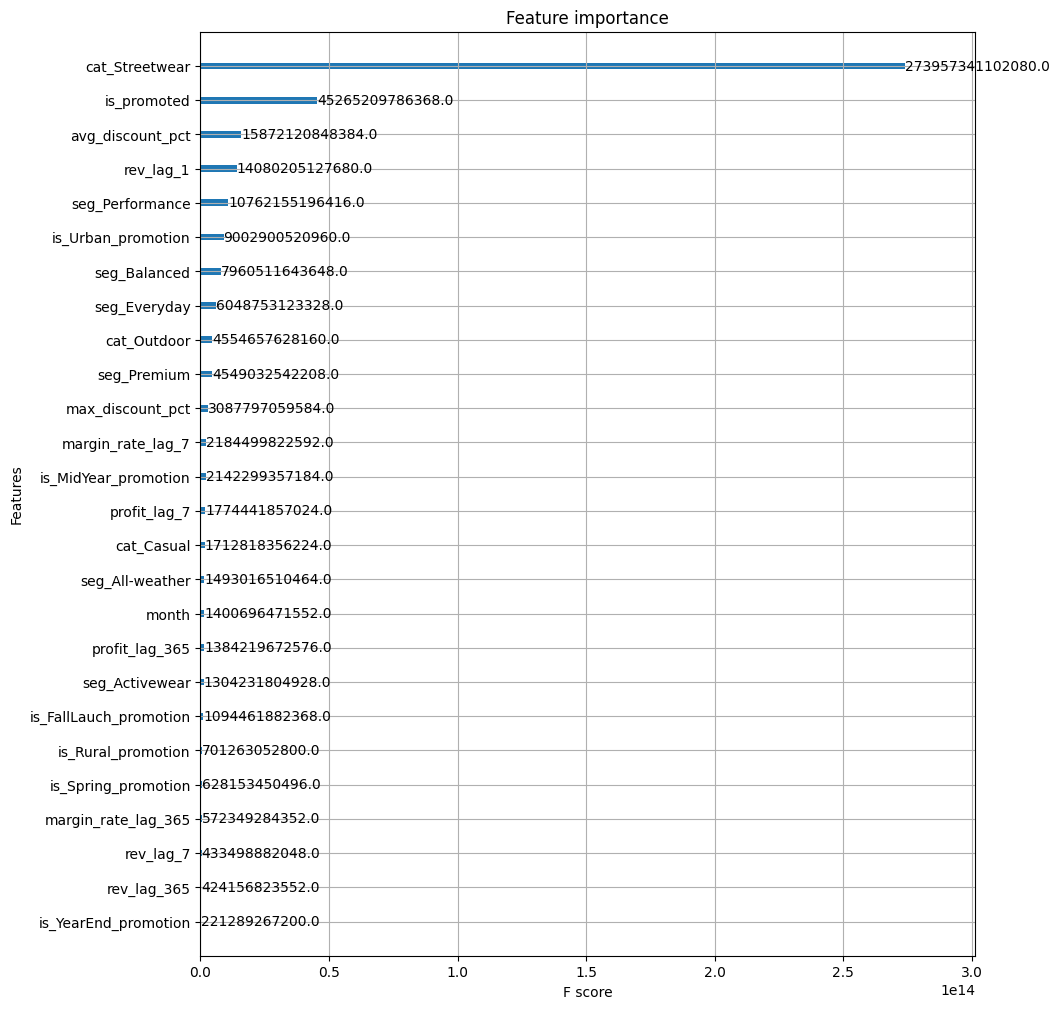

In [6]:
# 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_model, importance_type='gain', ax=ax)
plt.show()

In [7]:
# Khai báo best_param dựa trên optuna đã cũng cấp
best_param={
    'n_estimators': 1953,
    'max_depth': 3, 
    'learning_rate': 0.022210899333379032, 
    'subsample': 0.5897585582641189, 
    'colsample_bytree': 0.99483762099123, 
    'reg_alpha': 0.10802790127558719, 
    'reg_lambda': 0.0100321642152161
}
model_rev = XGBRegressor(**best_param, random_state=42)
model_rev.fit(df_daily[final_features], df_daily['Revenue'])

model_cogs= XGBRegressor(**best_param, random_state=42)
model_cogs.fit(df_daily[final_features], df_daily['COGS'])

print("✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!")

✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!


In [8]:
tscv = TimeSeriesSplit(n_splits=5)
scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}
# ĐÁNH GIÁ MÔ HÌNH REVENUE
cv_rev = cross_validate(model_rev, df_daily[final_features], df_daily['Revenue'], 
                         cv=tscv, scoring=scoring)

# ĐÁNH GIÁ MÔ HÌNH COGS
cv_cogs = cross_validate(model_cogs, df_daily[final_features], df_daily['COGS'], 
                          cv=tscv, scoring=scoring)

# TỔNG KẾT KẾT QUẢ
print(f"[REVENUE] Local RMSE: {np.sqrt(-cv_rev['test_mse'].mean()):,.2f} | R²: {cv_rev['test_r2'].mean():.4f}")
print(f"[COGS]    Local RMSE: {np.sqrt(-cv_cogs['test_mse'].mean()):,.2f} | R²: {cv_cogs['test_r2'].mean():.4f}")

[REVENUE] Local RMSE: 431,660.02 | R²: 0.9684
[COGS]    Local RMSE: 342,166.83 | R²: 0.9682


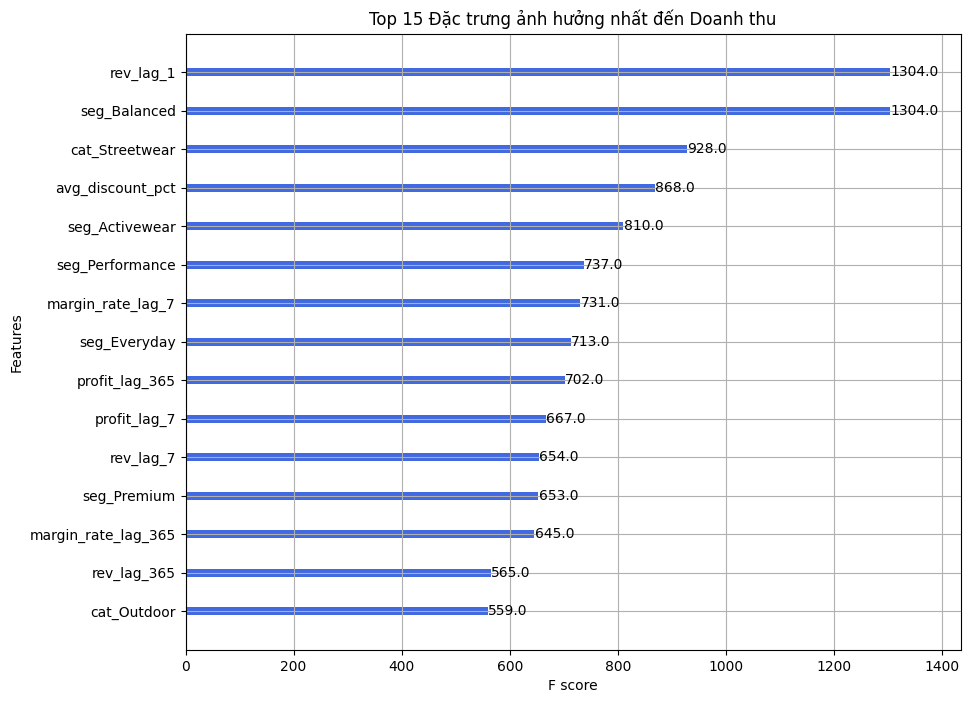

In [9]:
# 1. Thiết lập kích thước biểu đồ
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Vẽ biểu đồ quan trọng (Dùng 'weight' để xem tần suất biến đó được dùng để phân loại)
plot_importance(model_rev, ax=ax, max_num_features=15, importance_type='weight', color='royalblue')

plt.title("Top 15 Đặc trưng ảnh hưởng nhất đến Doanh thu")
plt.show()

In [10]:
ALL_DATES = sorted(df_daily['Date'].unique())

def get_lag_safe(date_obj, lag_days, key, hist_dict):
    target_date = date_obj - pd.Timedelta(days=lag_days)
    
    if target_date in hist_dict:
        return hist_dict[target_date].get(key, 0)
    
    valid_dates = [d for d in ALL_DATES if d <= target_date]
    if valid_dates:
        closest_date = valid_dates[-1]
        if abs((closest_date - target_date).days) <= 3:
            return hist_dict.get(closest_date, {}).get(key, 0)
    return 0

In [11]:
def get_promo_features_for_single_date(current_date):
    year = current_date.year
    month_day = current_date.strftime('%m-%d')
    
    is_spring = 1 if '03-18' <= month_day <= '04-17' else 0
    is_midyear = 1 if '06-23' <= month_day <= '07-22' else 0
    is_fall = 1 if ('08-30' <= month_day <= '10-01') or ((year % 4 == 1) and month_day == '10-02') else 0
    is_yearend = 1 if ('11-18' <= month_day <= '12-31') or ('01-01' <= month_day <= '01-02') else 0
    
    is_rural = 1 if (year % 2 == 1) and ('01-30' <= month_day <= '03-01') else 0
    is_urban = 1 if (year % 2 == 1) and ('07-30' <= month_day <= '09-02') else 0
    # Thêm biến này để model biết có khuyến mãi
    is_promoted_flag = 1 if (is_spring or is_midyear or is_fall or is_yearend or is_rural or is_urban) else 0
    # --- Decode ---
    cat_promo = -1
    if is_spring or is_midyear or is_yearend:
        cat_promo = 0
    if is_rural:
        cat_promo = 1
    if is_urban:
        cat_promo = 2
        
    chanel_promo = -1
    if is_spring or is_fall:
        chanel_promo = 4
    if is_rural:
        chanel_promo = 1
    if is_urban:
        chanel_promo = 2
    if is_midyear:
        chanel_promo = 3
    if is_yearend:
        chanel_promo = 0
        
    return {
        'is_promoted': is_promoted_flag,
        'is_Spring_promotion': is_spring,
        'is_MidYear_promotion': is_midyear,
        'is_FallLauch_promotion': is_fall,
        'is_YearEnd_promotion': is_yearend,
        'is_Rural_promotion': is_rural,
        'is_Urban_promotion': is_urban,
        'category_promotion': cat_promo,
        'chanel_promotion': chanel_promo
    }

In [12]:
# Tạo tập validation (năm 2022)
val_start = '2022-01-01'
val_end = '2022-12-31'

# Lấy các ngày còn lại của tập train để làm lịch sử cho validation
historical_val = df_daily[df_daily['Date'] < val_start][['Date', 'Revenue', 'Profit', 'avg_discount_pct', 'max_discount_pct']].copy()
historical_val = historical_val.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_val_dict = historical_val.set_index('ds').to_dict('index')

# Tạo đặc trưng tĩnh theo tháng
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear']
].mean().to_dict('index')

# Tìm tỷ lệ blending tối ưu
best_score = float('inf')
best_ratio = 0.5
best_growth = 1.00

print("Đang tìm tỷ lệ blending tối ưu...")
for growth in [0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05]:
    for ratio in [0.45, 0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        val_results = []
        temp_dict = historical_val_dict.copy()
        
        for current_date in pd.date_range(start=val_start, end=val_end):
            month = current_date.month
            promo_features = get_promo_features_for_single_date(current_date) # Tạo biến để tích hợp hàm vào ngày đang xét
            current_features = {
                'month': month,
                'day_of_week': current_date.dayofweek,
                'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
                'rev_lag_1': get_lag_safe(current_date, 1, 'y', temp_dict),
                'rev_lag_7': get_lag_safe(current_date, 7, 'y', temp_dict),
                'rev_lag_365': get_lag_safe(current_date, 365, 'y', temp_dict),
                'profit_lag_7': get_lag_safe(current_date, 7, 'profit', temp_dict),
                'profit_lag_365': get_lag_safe(current_date, 365, 'profit', temp_dict),
                'avg_discount_pct': get_lag_safe(current_date, 365, 'avg_discount_pct', temp_dict),
                'max_discount_pct': get_lag_safe(current_date, 365, 'max_discount_pct', temp_dict)
            }
            # Cập nhật các biến khuyến mãi vào current_features
            current_features.update(promo_features) # Update từ biến promo_features
            # Tính margin_rate_lag_7
            rev_lag_7 = get_lag_safe(current_date, 7, 'y', temp_dict)
            profit_lag_7_val = current_features['profit_lag_7']
            current_features['margin_rate_lag_7'] = profit_lag_7_val / (rev_lag_7 + 1)
            # Tính margin_rate_lag_365
            rev_lag_365 = get_lag_safe(current_date, 365, 'y', temp_dict)
            profit_lag_365_val = current_features['profit_lag_365']
            current_features['margin_rate_lag_365'] = profit_lag_365_val / (rev_lag_365 + 1)

            # Thêm đặc trưng tĩnh
            for k, v in train_monthly_avg.get(month, {}).items():
                current_features[k] = v
            
            X_pred = pd.DataFrame([current_features])[final_features]
            revenue_pred = model_rev.predict(X_pred)[0]
            cogs_pred = model_cogs.predict(X_pred)[0]
            
            hist_rev = get_lag_safe(current_date, 365, 'y', temp_dict)
            hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', temp_dict) if hist_rev > 0 else 0
            
            final_rev = (hist_rev * growth * ratio) + (revenue_pred * (1 - ratio))
            final_cogs = (hist_cogs * growth * ratio) + (cogs_pred * (1 - ratio))
            
            temp_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs, 'avg_discount_pct': current_features['avg_discount_pct'], 
                'max_discount_pct': current_features['max_discount_pct']}
            val_results.append({'Date': current_date, 'Revenue': final_rev, 'COGS': final_cogs})
        
        # Đánh giá
        val_df = pd.DataFrame(val_results)
        actual_train = df_daily[df_daily['Date'].between(val_start, val_end)]
        val_merged = val_df.merge(actual_train[['Date', 'Revenue', 'COGS']], on='Date', suffixes=('_pred', '_actual'))
        
        mse_rev = mean_squared_error(val_merged['Revenue_actual'], val_merged['Revenue_pred'])
        mse_cogs = mean_squared_error(val_merged['COGS_actual'], val_merged['COGS_pred'])
        total_mse = mse_rev + mse_cogs
        
        if total_mse < best_score:
            best_score = total_mse
            best_ratio = ratio
            best_growth = growth

print(f"\nTỶ LỆ BLENDING TỐI ƯU:")
print(f"   - History weight: {best_ratio:.0%}")
print(f"   - AI weight:      {1-best_ratio:.0%}")
print(f"   - Growth factor:  {best_growth}")
print(f"   - Best MSE:       {best_score:,.2f}")

Đang tìm tỷ lệ blending tối ưu...

TỶ LỆ BLENDING TỐI ƯU:
   - History weight: 70%
   - AI weight:      30%
   - Growth factor:  0.96
   - Best MSE:       1,763,380,400,276.13


In [13]:
print("Bắt đầu quá trình dự đoán tuần tự...")

# Khởi tạo mỏ neo lịch sử
start_pred_date = pd.to_datetime('2023-01-01')
historical_df = df_daily[df_daily['Date'] < start_pred_date][['Date', 'Revenue', 'Profit', 'avg_discount_pct', 'max_discount_pct']].copy()
historical_df = historical_df.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_dict = historical_df.set_index('ds').to_dict('index')

future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
results = []

# Các đặc trưng tĩnh (không thay đổi theo thời gian hoặc lấy trung bình tháng)
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear']
].mean().to_dict('index')

start_pred_date = pd.to_datetime('2023-01-01')
total_pred_days = 547
# Dự đoán tuần tự
for current_date in tqdm(future_dates, desc="Đang dự đoán"):
    month = current_date.month
    promo_features = get_promo_features_for_single_date(current_date) # Tạo biến để tích hợp hàm vào ngày đang xét
    # Tạo feature cho ngày hiện tại
    current_features = {
        'month': month,
        'day_of_week': current_date.dayofweek,
        'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
        'profit_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict),
        'rev_lag_1': get_lag_safe(current_date, 1, 'y', historical_dict),
        'rev_lag_7': get_lag_safe(current_date, 7, 'y', historical_dict),
        'rev_lag_365': get_lag_safe(current_date, 365, 'y', historical_dict),
        'profit_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict),
        'margin_rate_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict) / (get_lag_safe(current_date, 7, 'y', historical_dict) + 1),
        'margin_rate_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict) / (get_lag_safe(current_date, 365, 'y', historical_dict) + 1),
        'avg_discount_pct': get_lag_safe(current_date, 365, 'avg_discount_pct', historical_dict),
        'max_discount_pct': get_lag_safe(current_date, 365, 'max_discount_pct', historical_dict)
    }
    current_features.update(promo_features) # Update từ biến promo_features
    # Thêm các đặc trưng tĩnh từ dữ liệu trung bình tháng
    for k, v in train_monthly_avg.get(month, {}).items():
        current_features[k] = v

    # Dự đoán Doanh thu và Giá vốn
    X_pred = pd.DataFrame([current_features])[final_features]
    revenue_pred = model_rev.predict(X_pred)[0]
    cogs_pred = model_cogs.predict(X_pred)[0]

    # Blending
    hist_rev = get_lag_safe(current_date, 365, 'y', historical_dict)
    hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', historical_dict) if hist_rev > 0 else 0
    
    # Lấy tỷ lệ Blending của growth_factor được chạy từ code trên
    # Dùng cơ chế trượt khi ở giai đoạn đầu model sẽ đoán đúng cao hơn nhưng giai đoạn sau sẽ dẫn đến sai số tích luỹ nên cần lấy lịch sử làm mỏ neo
    days_passed = (current_date - start_pred_date).days
    ai_weight = 0.85 - (0.60 * (days_passed / total_pred_days))
    hist_weight = 1.0 - ai_weight
    growth_factor = 0.96

    # Công thức gộp
    final_rev = (hist_rev * growth_factor * hist_weight) + (revenue_pred * ai_weight)
    final_cogs = (hist_cogs * growth_factor * hist_weight) + (cogs_pred * ai_weight)

    # Cập nhật kết quả vào historical_dict cho các lần dự đoán tiếp theo
    historical_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs, 
        'avg_discount_pct': current_features['avg_discount_pct'], 'max_discount_pct': current_features['max_discount_pct']}
    
    # Lưu kết quả
    results.append({
        'Date': current_date.strftime('%Y-%m-%d'),
        'Revenue': final_rev,
        'COGS': final_cogs
    })

# Tạo và lưu file submission
submission_final = pd.DataFrame(results)
submission_final.to_csv('submission_khang_fixed_v14.csv', index=False)
print(f"✅ File 'submission_khang_fixed_v14.csv' đã sẵn sàng nộp.")

Bắt đầu quá trình dự đoán tuần tự...


Đang dự đoán: 100%|██████████| 548/548 [00:03<00:00, 155.72it/s]

✅ File 'submission_khang_fixed_v14.csv' đã sẵn sàng nộp.
